In [84]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


# Sesión 7 Laboratorio de Computación Cuántica 2

## Algoritmo de busqueda de Grover

Imagina que tienes una lista de N datos, y tienes que buscar uno de esos datos entre toda esa linea. Para ello, tienes que buscar entre todo el conjunto un dato, ¿Cual es la complejidad computacional de esto?

Pues en el mejor de los casos, lo encuentras a la primera, en el peor, te toma un total de N iteraciones. En promedio, te va a tomar un total de $\frac{N}{2}$ intentos encontrar el dato que estas buscando, por lo cual su complejidad es de $O(N)$. Esto no esta tan mal, pero existe una forma de buscar estos datos de manera mas eficiente. Otra forma de representarlo es, imagina que tienes una caja negra $f$, la cual, si x es el elemento que buscas, $f(x)=1$, caso contrario, $f(x)=0$, ¿Cuantas iteraciones de $f$ necesitas para encontrar el elemento que buscas?

### Inversión sobre la media y el Difusor de Grover

Vamos a entender la idea principal sobre la cual el algoritmo de Grover se basa: La inversión sobre la media

Por el momento olvidemonos de lo cuántico. Imagina que tenemos un conjunto de valores $x_1,x_2,...,x_N$, su promedio de estos valores es $\bar{x}=\frac{1}{N}\sum_{i=1}^{N}x_i$ y la inversión sobre la media lo que hace es que refleja el valor con respecto del promedio, es decir, al valor $x_i$ le asocia el valor $2\bar{x}-x_i$. Esto es simplemente, si ves a la media como un espejo, la inversión sobre la media te coloca en el otro lado del espejo.

Ej: Si tenemos os valores 1,2,3 entonces, la media es 2, el reflejo del 1 con respecto a la media es 3, el del 2, es el 2, y el del 3, es el 1

Ahora, apliquemoslo a cuántica.

Aquí trabajamos con estados, $|\psi\rangle=\sum_ia_i|i\rangle$

En este estado, la media de las amplitudes asociadas a cada ket es precisamente $\bar{a}=\frac{1}{N}\sum_{i=1}a_i$ y para aplicar la inversión sobre la media, se implementa como un operador sobre el sistema, el cual es: $D=2|s\rangle\langle s|-I$ donde $|s\rangle=\frac{1}{\sqrt{N}}\sum_i|i\rangle$. Este operador se le conoce como el Difusor de Grover

Actividad de Tarea 1 (Grover): Demuestra que el difusor de grover realiza la inversión sobre la media

### Lógica e implementación del algoritmo de Busqueda de Grover

Explicaremos como el algoritmo de busqueda de Grover funciona y como nos va a ayudar a realizar la búsqueda.

Primero, imagina que tenemos un total de N elementos, entonces, busquemos que la cantidad de qubits $n=\log_2(N)$ qubits, dentro de los cuales podemos estudiar $2^n>N$ posibles estados. Imaginemos que el estado que buscamos sea alguno de estos estados, lo vamos a llamar $|r\rangle$

Para ello, aplicamos compuertas Hadamard en todo el sistema inicial para preparar una superposición uniforme $|s\rangle=\frac{1}{\sqrt{N}}\sum_x=0$. Con eso generamos una superposición uniforme de todo el sistema. 

Ahora, aquí vamos a trabajar con un oráculo $\hat{O}$, el oráculo de grover. Este Oráculo cumple la siguiente condición: $\hat{O}|x\rangle=|x\rangle$ si $|x\rangle\neq|r\rangle$ y $\hat{O}|r\rangle=-|r\rangle$. Es decir, el oráculo de grover CAMBIA el signo de la amplitud del elemento que estas buscando.

Despues de aplicar el oráculo de grover, aplicas el Difusor de grover (que ya vimos como funciona) para aplicar la inversión sobre la media. Veamos que pasa cuando realizamos esto

#### Oráculo de Grover

Podemos ver el oráculo de grover como $O_f= I-2|r\rangle\langle r |$ y esto lo que realiza es precisamente el efecto del oráculo de grover 

Actividad de Tarea 2 (Grover): ¿Por que el oráculo de grover tiene ese efecto? ¿Es algún tipo de reflexión similar a la reflexión sobre la media?

In [85]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

#### Ciencia de los operadores

El oráculo de grover y el difusor de grover no son operaciones que se puedan implementar asi nada mas. Para implementarlas, es necesario entender que herramientas tenemos a nuestra disposición y que operaciones podemos realizar. Veamos como se aplican el Oráculo de Grover y el Difusor de Grover

##### Oráculo de Grover

Para aplicar el oráculo de grover, su ecuación es $O_f= I-2|r\rangle\langle r |$ que justamente cambia el signo del dato que buscamos pero mantiene el resto igual. ¿Como lo aplicamos? 

Lo primero que hacemos es que identificamos los strings del estado que estamos buscando, y convertimos ese estado en el estado de puros unos aplicando compuertas x, (Por ejemplo, si el estado que buscamos es el $|101\rangle$, entonces aplicamos una x en el segundo qubit, eso convertira el estado $|101\rangle$ en el estado $|111\rangle$). Ahora, y esto es lo importante, aplicamos una compuerta controlada z entre todos los qubits, con el ultimo qubit. Esta operación es sumamente importante, pues es una operación que cambia el signo unicamente del estado $|111\rangle$ y deja el resto de estados intactos. Para aplicarlos, vale la pena recordar que $HXH=Z$ (Actividad de Tarea 3: Demostrarlo) y aplicar una compuerta hadamard, luego una compuerta Toffolo (CCNOT) con todos los qubits y luego nuevamente un hadamard. Posteriormente, volvemos a aplicar las compuertas x que aplicamos anteriormente para regresar el estado $|r\rangle$

##### Difusor de grover

Este es interesante, pues $D=2|s\rangle\langle s|-I$ con $|s\rangle$ el estado de superposición total. Aqui la clave es entender que podemos convertir este estado $|s\rangle$ en el estado $|00...0\rangle$ implemente aplicando hadamards en el sistema, pues es facil ver que $D=H^{\otimes n}(2|0\rangle\langle 0|-I) H^{\otimes n}$ y lo que esta adentro se resume en que el estado $|0\rangle$ se mantiene igual, mientras que el resto de estados, todos, cambian el signo. Para ello llevamos el estado $|00...0\rangle$ al estado $|11...1\rangle$ aplicando X en todo el sistema y revertimos lo hecho

In [86]:
#Definimos el oráculo de grover y el difusor de grover

def oraculo_grover(target):
    n = len(target)
    qc = QuantumCircuit(n)
    
    target_bits = [int(b) for b in target]
    
    qc.barrier()  # Agregamos una barrera para separar visualmente el oráculo del resto del circuito
    # Convertimos el estado r a el estado |11...1> para aplicar la fase flip
    for i, bit in enumerate(target_bits):
        if bit == 0:
            qc.x(i)
    
    # aplicamos compuerta controlada z controlada por los primeros n-1 qubits y con el ultimo como objetivo
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    # Deshacemos la transformación para volver al estado original
    for i, bit in enumerate(target_bits):
        if bit == 0:
            qc.x(i)
    qc.barrier()  # Agregamos una barrera para separar visualmente el oráculo del resto del circuito
    return qc

def difusor_grover(n):
    qc = QuantumCircuit(n)

    qc.h(range(n))
    qc.x(range(n))
    
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    
    qc.x(range(n))
    qc.h(range(n))
    qc.barrier()
    return qc

In [87]:
n = 3
target = '101'

In [88]:
qc = QuantumCircuit(n, n)

In [89]:
qc.h(range(n))

In [90]:
oraculo = oraculo_grover(target)
difusor = difusor_grover(n)

qc = qc.compose(oraculo)
qc = qc.compose(difusor)

In [91]:
qc.measure(range(n), range(n)) # Medimos los qubits para obtener el resultado

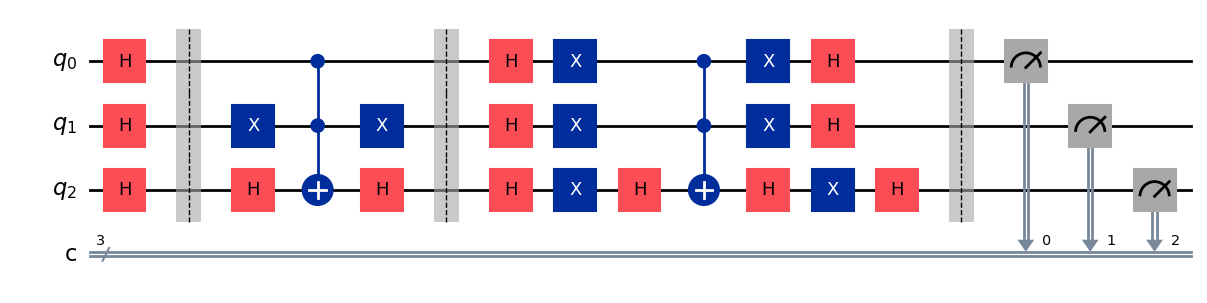

In [92]:
qc.draw('mpl')

{'101': 805, '011': 27, '001': 34, '100': 36, '010': 27, '000': 19, '110': 38, '111': 38}


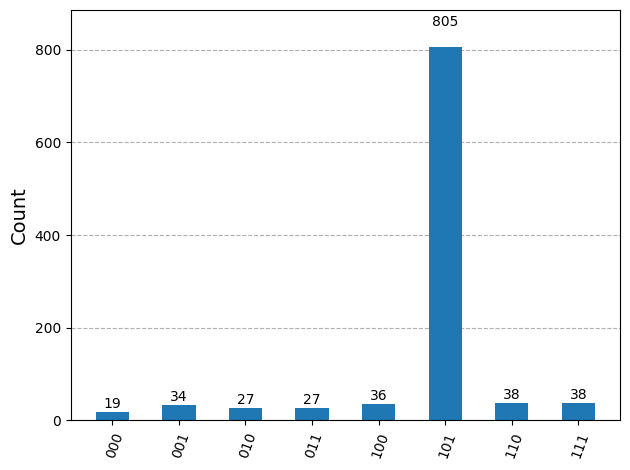

In [93]:
backend = AerSimulator(method='statevector')

compiled = transpile(qc, backend)
result = backend.run(compiled, shots=1024).result()

counts = result.get_counts()
print(counts)

plot_histogram(counts)

### Iteraciones de Grover y probabilidades

Como acabas de ver, las probabilidades aun no son completamente uniformos, si destaca un string pero aun hay probabilidad real de obtener otro string. Para busquedas mas grandes, esto se convierte en un problema importante ¿Como resolvemos esto? El algoritmo puede realizar diversas iteraciones en su interior para disminuir las probabilidades de valores no deseados al mínimo y maximizar la de los valores que si buscamos

#### Ángulo de Grover

Imagina de hecho que todo el algoritmo de Grover lo podemos entender como un trabajo en 2 subespacios:

El espacio solución, de dimensión uno, cuyo elemento es $|r\rangle$
El espacio ortogonal o tangente, que no toma en cuenta al espacio solución, que esta dado por la superposición de todo lo demas y su "base" es $|r^{\perp}\rangle=\frac{1}{\sqrt{N-1}}\sum_{x\neq r} |x\rangle$

Entonces, el estado inicial de grover de superposición es:

$$|s\rangle=\frac{1}{\sqrt{N}}|r\rangle+\sqrt{\frac{N-1}{N}}|r^{\perp}\rangle$$

Ahora, nosotros podemos representar a $|s\rangle=\sin(\theta)|r\rangle+\cos(\theta)|r^{\perp}\rangle$ definiendo $\sin(\theta)=\frac{1}{\sqrt{N}}$ y $\cos(\theta)=\sqrt{\frac{N-1}{N}}$, este es el ángulo de Grover

Ahora, primero aplicamos el Oráculo de Grover y luego el Difusor de Grover. A este conjunto de aplicaciones simultaneas se le conoce como el **Operador de Grover** y le llamaremos $G=D*O$, y tiene el efecto de que el estado final tras la aplicacion del operador de grover K veces acaba siendo:

$$|\psi_k\rangle = \sin((2k+1)\theta)|r\rangle + \cos((2k+1)\theta) |r^{\perp}\rangle$$

#### Probabilidad de éxito del algoritmo de Grover

La probabilidad de éxito esta dada por la probabilidad de medir $|r\rangle$, de modo que esta misma gira en torno al coeficiente $\sin((2k+1)\theta)$. La probabilidad de éxito es entonces $P_k=sin^2((2k+1)\theta)$ y esta se acerca a uno cuando $(2k+1)\theta \approx \frac{\pi}{2}$

Por medio de derivaciones matemáticas, esto se da cuando $k=\frac{\pi}{4\theta}-\frac{1}{2}$ y para N muy grande, recordemos que $\sin(\theta)\approx \theta$ y $\sin(\theta)=\frac{1}{\sqrt{N}}$, de manera que k se convierte en $k\approx \frac{\pi}{4}\sqrt{N}-\frac{1}{2}$, por lo cual $k=O(\sqrt{N})$

In [94]:
n = 6
target = '101011'   

N = 2**n
k = int(np.round((np.pi/4)*np.sqrt(N)))  
print("Iteraciones óptimas:", k)

Iteraciones óptimas: 6


In [95]:
qc = QuantumCircuit(n, n)

In [96]:
qc.h(range(n))
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [97]:
oracle = oraculo_grover(target)
diffuser = difusor_grover(n)

for _ in range(k):
    qc = qc.compose(oracle)
    qc = qc.compose(diffuser)

In [98]:
qc.measure(range(n), range(n))

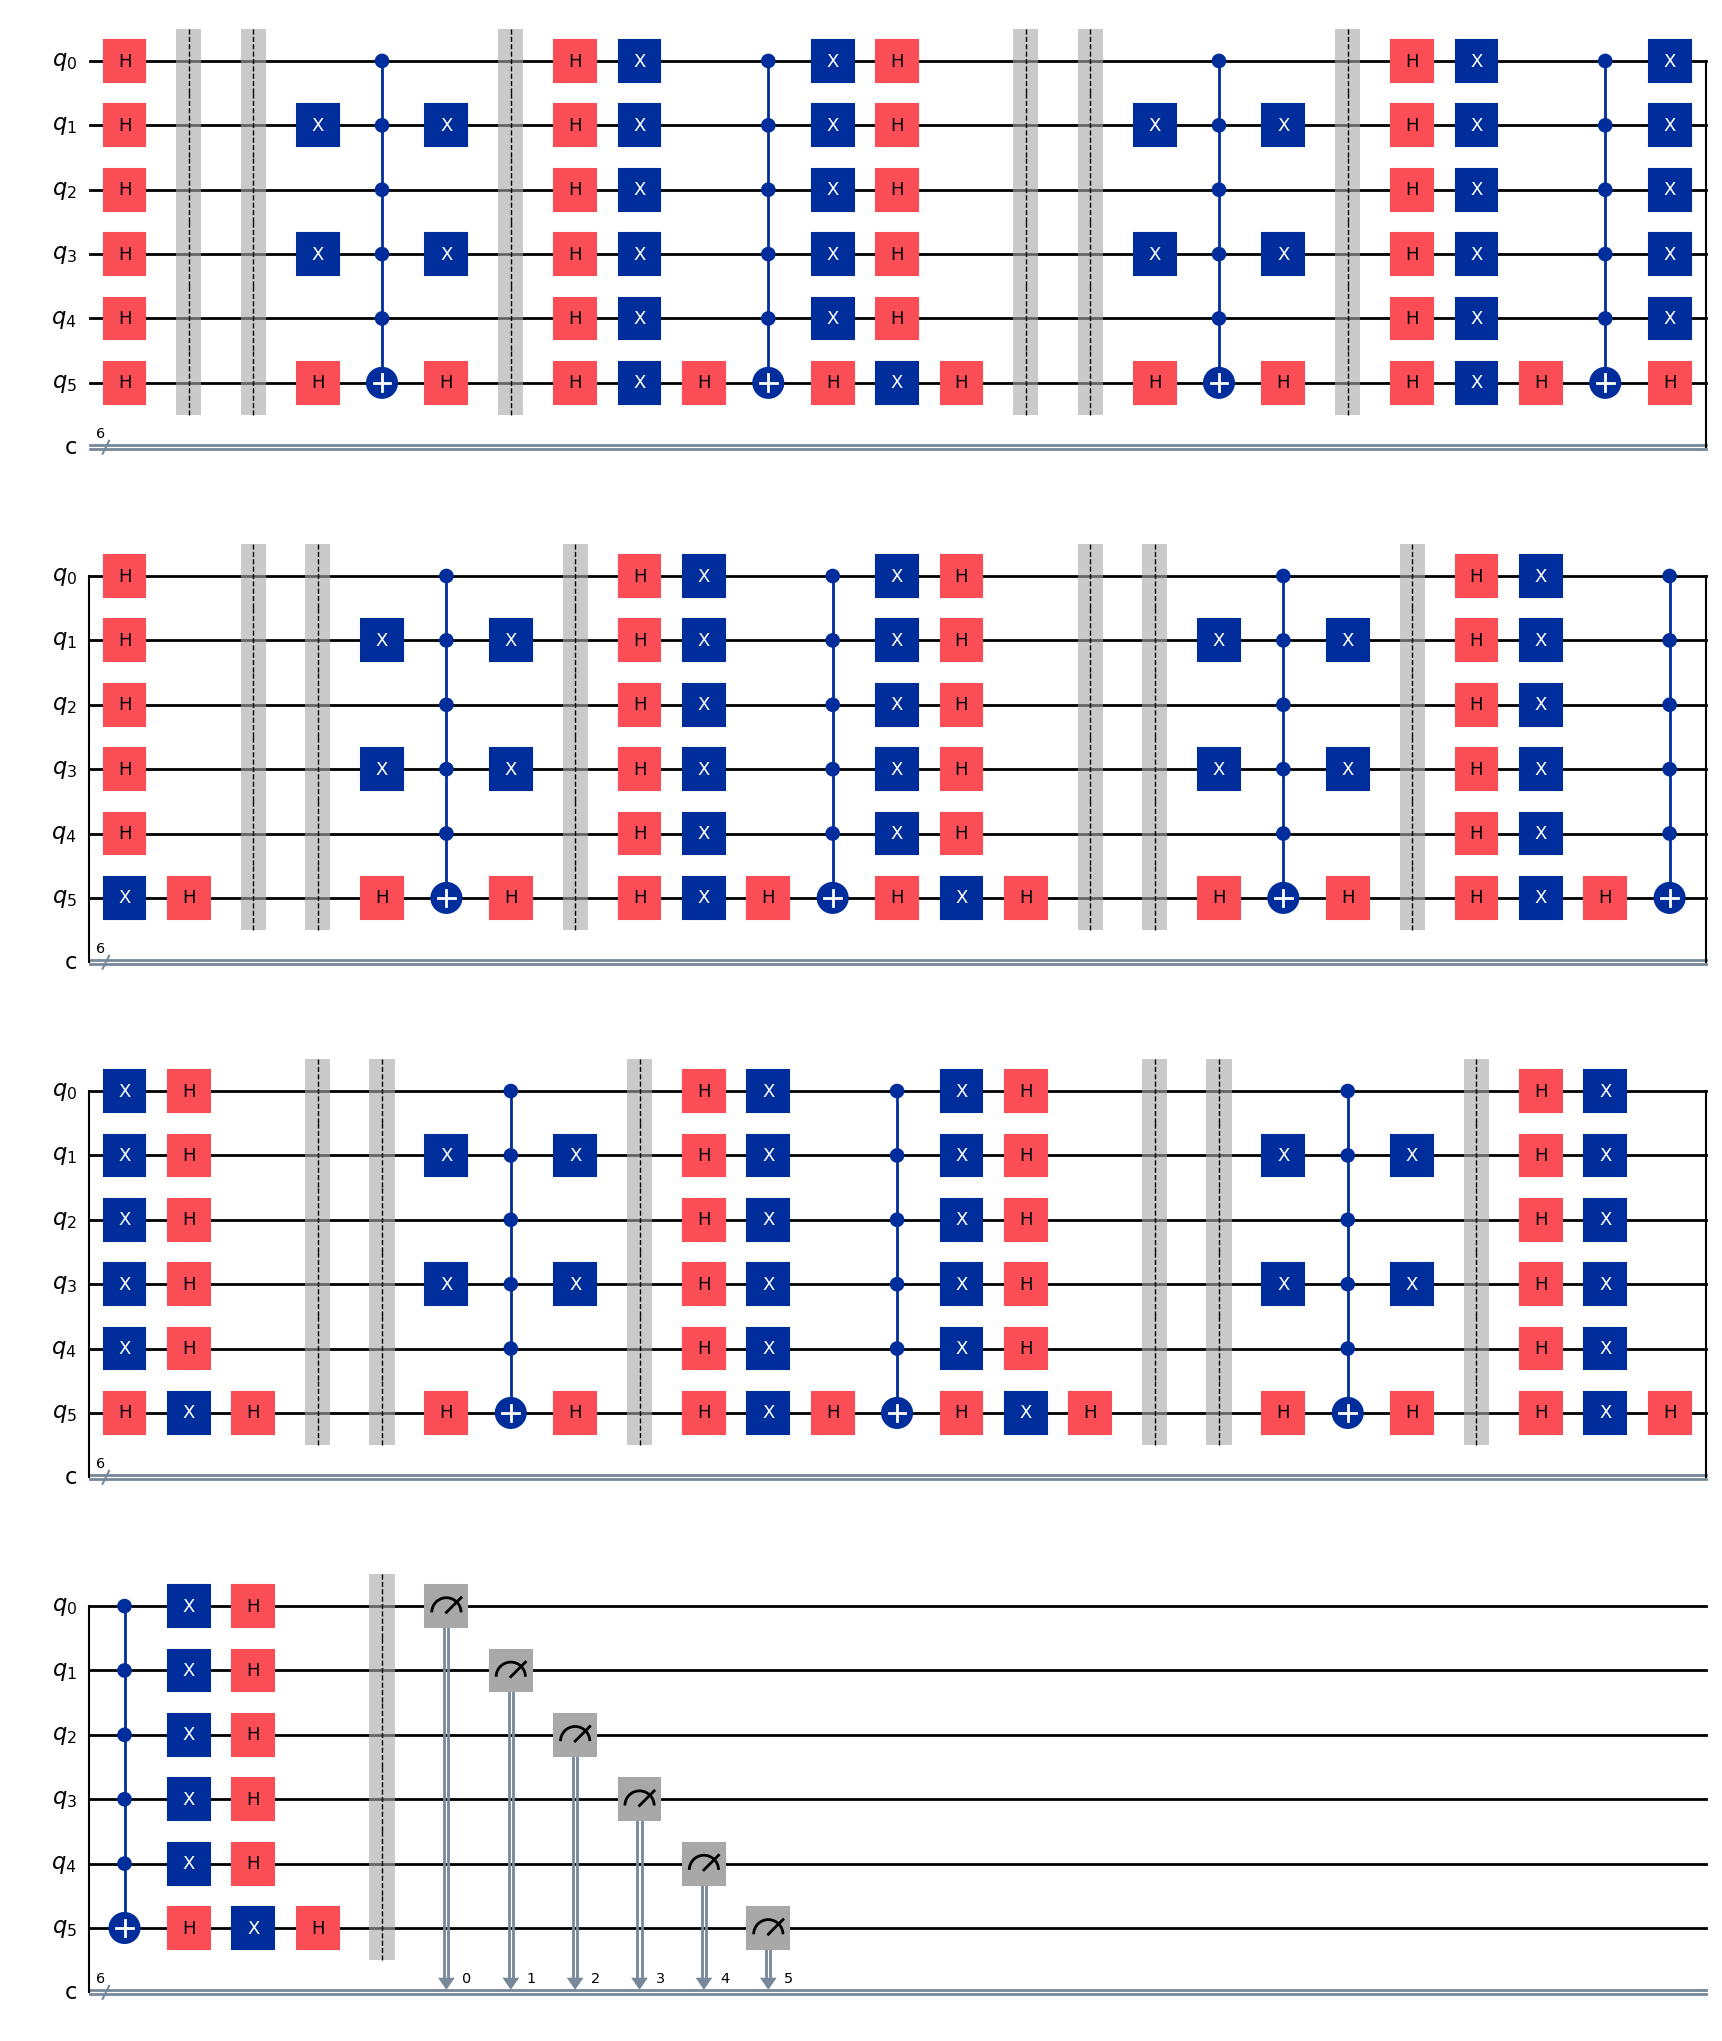

In [99]:
qc.draw('mpl')

{'100010': 1, '110101': 1019, '011011': 2, '111101': 1, '011111': 1}


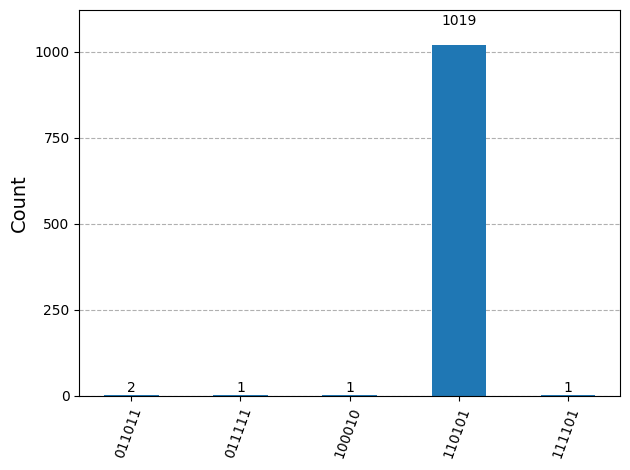

In [100]:
backend = AerSimulator(method='statevector')

compiled = transpile(qc, backend)
result = backend.run(compiled, shots=1024).result()

counts = result.get_counts()
print(counts)

plot_histogram(counts)

## References

The explanations, code, examples, exercises, and pedagogical presentation in this notebook were written by Benjamín Sánchez Hernández.

This notebook was prepared as a pedagogical synthesis based on standard references, technical documentation, and supplementary consultation:

1. Lov K. Grover. *A fast quantum mechanical algorithm for database search*. arXiv:quant-ph/9605043, 1996.  
   Original reference for Grover's search algorithm.

2. Michael A. Nielsen and Isaac L. Chuang. *Quantum Computation and Quantum Information*, 10th Anniversary Edition. Cambridge University Press, 2010.  
   Theoretical reference for Grover's algorithm, quantum oracles, amplitude amplification, and the diffusion operator.

3. IBM Quantum Documentation. *Grover operator*.  
   Technical and conceptual reference for the phase oracle, diffusion operator, and Grover operator formulation.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.grover_operator

4. IBM Quantum Documentation. *QuantumCircuit API Reference*.  
   Technical reference for circuit construction, gate application, composition, multi-controlled gates, and measurements.  
   https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.QuantumCircuit

5. Qiskit Aer Documentation. *AerSimulator*.  
   Technical reference for simulating quantum circuits and obtaining measurement counts.  
   https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html

6. Supplementary educational videos and online explanations were consulted to compare pedagogical presentations of amplitude amplification, inversion about the mean, and the geometric interpretation of Grover iterations.